# 02 — Baseline model (VGG-6 od nule)

Cilj ovog notebook-a je da istreniramo jednostavnu konvolucionu mrežu **od nule** (bez unapred naučenih težina) kao **baseline** — donju granicu performansi za poređenje sa transfer learning (`03`) i fine-tuning (`04`) pristupima.

Arhitektura prati VGG-6 iz referentnog rada (Lin, 2020, Fig. 3): 4 bloka Conv2D+MaxPooling2D, pa Dense slojevi. Prvo treniramo BEZ regularizacije da vidimo overfitovanje uživo, pa dodajemo Dropout i data augmentation da ga ispravimo — isto kao što rad opisuje.

Koristi se `split.csv` napravljen u `01_data_exploration.ipynb` (train/val/test 80/16/4, stratifikovano, seed 42) — split se ovde NE pravi ponovo.


## 1. Setup

Isti obrazac kao u prethodnim notebook-ima: provera verzije TensorFlow-a, montiranje Google Drive-a, provera GPU-a, i fiksni random seed radi ponovljivosti rezultata.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow verzija:", tf.__version__)

TensorFlow verzija: 2.20.0


In [ ]:
# montiramo Google Drive da bi podaci (split.csv, kasnije model) ostali sačuvani između sesija
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# GPU treba biti uključen ručno za svaki NOVI notebook (Runtime -> Change runtime type -> T4 GPU)
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print("GPU je dostupan:", gpu_devices)
else:
    print("GPU NIJE dostupan — proveri Runtime → Change runtime type")

GPU je dostupan: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# fiksni seed svuda gde ima nasumičnosti (shuffle, augmentacija, inicijalizacija težina) - isti kao u 01 i 03, radi ponovljivosti
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Učitavanje split.csv i priprema podataka

Učitavamo VEĆ NAPRAVLJEN train/val/test split (napravljen u `01_data_exploration.ipynb`) i pravimo pune putanje do slika, pa mapiramo tekstualne labele (`cat`/`dog`) u brojeve (0/1) potrebne modelu.


In [ ]:
# učitavamo VEĆ NAPRAVLJEN split iz notebook-a 01 (ne pravimo split ponovo!)
SPLIT_PATH = "/content/drive/MyDrive/MU-projekat/data/split.csv"
split_df = pd.read_csv(SPLIT_PATH)

DATASET_DIR = "/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats/train/train"

# split.csv sadrži samo imena fajlova - pravimo punu putanju do svake slike
split_df["filepath"] = split_df["filename"].apply(
    lambda filename: os.path.join(DATASET_DIR, filename)
)

train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (20000, 4)
Validation: (4000, 4)
Test: (1000, 4)


In [ ]:
IMG_SIZE = 224   # isto kao kod Mininog VGG-16 notebook-a, radi doslednosti
BATCH_SIZE = 32

# modeli ne razumeju tekstualne labele - mapiramo cat/dog u 0/1
label_to_index = {"cat": 0, "dog": 1}

for df in [train_df, val_df, test_df]:
    df["label_index"] = df["label"].map(label_to_index)

print(train_df[["filename", "label", "label_index"]].head())

        filename label  label_index
0   cat.5004.jpg   cat            0
1   dog.9777.jpg   dog            1
2   dog.2406.jpg   dog            1
3  dog.11980.jpg   dog            1
4  cat.10071.jpg   cat            0


## 3. Priprema tf.data pipeline-a

Gradimo `tf.data.Dataset` koji čita slike sa diska, menja im veličinu na 224×224 i skalira piksele u opseg [0, 1] (standardno skaliranje za model koji uči od nule — za razliku od Mininog pristupa koji koristi VGG-16-specifičan `preprocess_input`, jer ona koristi unapred trenirane ImageNet težine, a mi ne).


In [ ]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # NAPOMENA: za razliku od Mininog VGG-16 notebook-a (koji koristi preprocess_input
    # prilagođen ImageNet težinama), mi treniramo OD NULE, pa samo standardno
    # skaliramo piksele iz [0, 255] u [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [ ]:
def create_dataset(df, training=False):
    filepaths = df["filepath"].values
    labels = df["label_index"].values

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    # mešamo SAMO trening skup - validacija i test moraju ostati u istom redosledu
    if training:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # priprema sledeći batch dok se trenutni obrađuje
    return dataset


train_dataset = create_dataset(train_df, training=True)
val_dataset = create_dataset(val_df, training=False)
test_dataset = create_dataset(test_df, training=False)

# provera da je pipeline ispravan pre nego što krenemo dalje
for images, labels in train_dataset.take(1):
    print("Oblik batch-a:", images.shape)
    print("Min/Max piksel:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())

Oblik batch-a: (32, 224, 224, 3)
Min/Max piksel: 0.0 1.0


## 4. Arhitektura VGG-6 (bez regularizacije)

Prva verzija modela — namerno BEZ Dropout-a i BEZ augmentacije, da bismo mogli da vidimo overfitovanje uživo, kao što ga i referentni rad opisuje.

4 bloka `Conv2D` + `MaxPooling2D` (broj filtera raste sa dubinom: 32→64→128→128, pošto dublji slojevi prepoznaju sve složenije obrasce i treba im više "kanala" da ih predstave), pa `Flatten` → `Dense(512)` → `Dense(1, sigmoid)` za binarnu klasifikaciju. Optimizator je `RMSprop`, kako i rad navodi.

Primetiti: skoro svi parametri modela (12.8M od ukupno 13M) dolaze iz JEDNOG sloja (`Dense(512)`) — `Flatten` proizvodi vektor od 25.088 brojeva (14×14×128), a svaki se povezuje sa svakim od 512 neurona. Ova koncentracija parametara je glavni razlog zašto arhitektura lako overfituje.


In [ ]:
def build_baseline_model():
    # 4 bloka Conv2D + MaxPooling2D, broj filtera raste sa dubinom (32-64-128-128) - Fig.3 iz Lin (2020)
    # padding="same" čuva prostorne dimenzije nakon konvolucije, samo MaxPooling smanjuje dimenzije
    # NAMERNO nema Dropout ni augmentacije u ovoj verziji - hoćemo prvo da vidimo overfitovanje uživo
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Flatten pretvara poslednju "kocku" osobina (14x14x128) u ravan vektor od 25088 brojeva
        tf.keras.layers.Flatten(),
        # Dense(512) je najveći deo modela po broju parametara (25088x512 = ~12.8M veza) -
        # baš zato ova arhitektura lako overfituje
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")  # binarna klasifikacija: 0=cat, 1=dog
    ], name="vgg6_baseline")
    return model


baseline_model = build_baseline_model()
baseline_model.summary()

Model: "vgg6_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,086,913 (49.92 MB)

 Trainable params: 13,086,913 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Trening bez regularizacije (overfit demo)

**Napomena o problemu na koji smo naišle**: prvi pokušaj treninga čitao je slike direktno sa Google Drive-a. Pola epohe je trajalo oko 20 minuta — neodrživo sporo (cela epoha ~40 min × 20 epoha ≈ 13+ sati). Uzrok: Google Drive je mrežni fajl-sistem, svako čitanje pojedinačne slike ide preko mreže, a `shuffle` dodatno čita ih nasumičnim redosledom (najgori slučaj za mrežno čitanje).

**Rešenje**: kopiramo zip fajl dataseta (817MB, JEDAN fajl — brzo se kopira) na lokalni disk Colab mašine (`/content/`) i raspakujemo ga tamo. Trening koji čita sa lokalnog diska je bio ~40× brži (ispod minuta po epohi, umesto ~40 minuta). `/content/` se briše kad se Colab sesija ugasi, što je u redu — to je samo privremeni radni prostor tokom treninga, sve što trajno čuvamo (split.csv, model) i dalje ide na Drive.

Treniramo 20 epoha BEZ `EarlyStopping`-a — namerno, da vidimo pun tok overfitovanja na grafikonu koji sledi.


In [ ]:
# čistimo folder za slučaj da je ostao nepotpun raspakovan sadržaj iz prethodnog pokušaja
!rm -rf /content/dogs-vs-cats
# -o (overwrite) sprečava interaktivna pitanja ako fajlovi već postoje
!unzip -q -o /content/dogs-vs-cats.zip -d /content/dogs-vs-cats

In [ ]:
# slike sad čitamo sa LOKALNOG diska (/content/), ne sa Drive-a - vidi objašnjenje iznad
DATASET_DIR = "/content/dogs-vs-cats/train/train"

for df in [train_df, val_df, test_df]:
    df["filepath"] = df["filename"].apply(lambda filename: os.path.join(DATASET_DIR, filename))

train_dataset = create_dataset(train_df, training=True)
val_dataset = create_dataset(val_df, training=False)
test_dataset = create_dataset(test_df, training=False)

In [ ]:
# gradimo model IZNOVA (čist, netreniran) - prethodna instanca je bila delimično
# istrenirana u prekinutom pokušaju sa sporim Drive čitanjem
baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),  # RMSprop - isto kao u Lin (2020)
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
)

EPOCHS_OVERFIT_DEMO = 20

# NEMA EarlyStopping ovde - namerno, želimo da vidimo pun tok overfitovanja na grafikonu
history_overfit = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_OVERFIT_DEMO
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.6503 - loss: 0.6175 - val_accuracy: 0.7195 - val_loss: 0.5526
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.7343 - loss: 0.5262 - val_accuracy: 0.7725 - val_loss: 0.4768
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.7766 - loss: 0.4663 - val_accuracy: 0.7673 - val_loss: 0.4772
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8081 - loss: 0.4181 - val_accuracy: 0.8135 - val_loss: 0.4080
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 77ms/step - accuracy: 0.8268 - loss: 0.3810 - val_accuracy: 0.8263 - val_loss: 0.3971
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.8460 - loss: 0.3488 - val_accuracy: 0.8338 - val_loss: 0.3877
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8613 - loss: 0.3158 - val_accuracy: 0.8393 - val_loss: 0.3603
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.8759 - loss: 0.2867 - 

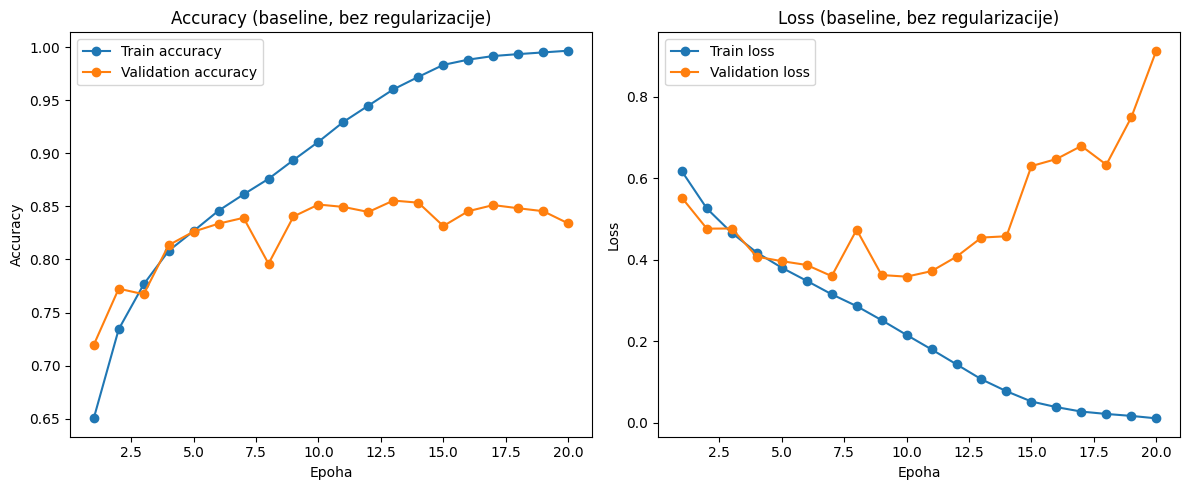

In [ ]:
# history.history je rečnik koji Keras automatski popunjava tokom fit() - niz vrednosti po epohi
train_accuracy = history_overfit.history["accuracy"]
val_accuracy = history_overfit.history["val_accuracy"]
train_loss = history_overfit.history["loss"]
val_loss = history_overfit.history["val_loss"]
epochs_range = range(1, len(train_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, train_accuracy, marker="o", label="Train accuracy")
axes[0].plot(epochs_range, val_accuracy, marker="o", label="Validation accuracy")
axes[0].set_title("Accuracy (baseline, bez regularizacije)")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range, train_loss, marker="o", label="Train loss")
axes[1].plot(epochs_range, val_loss, marker="o", label="Validation loss")
axes[1].set_title("Loss (baseline, bez regularizacije)")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Regularizovana verzija — Dropout + Data Augmentation

Dve izmene u odnosu na prvu verziju:

1. **Data augmentation** — nasumično menjamo trening slike (rotacija, zumiranje, horizontalno okretanje) da model vidi "nove" varijacije umesto uvek istih 20.000 slika, sprečavajući ga da ih zapamti napamet.
2. **Dropout(0.5)** — tokom treninga nasumično "gasimo" 50% neurona u `Dense(512)` sloju u svakom koraku, primoravajući model da nauči redundantnije, robusnije obrasce umesto da se osloni na specifične kombinacije neurona.

Isti optimizator/learning rate kao kod prve verzije — da razlika u rezultatima dolazi isključivo od regularizacije. Ovog puta koristimo `EarlyStopping` (prati `val_loss`, staje posle 5 epoha bez poboljšanja, vraća najbolje težine).


In [ ]:
# data augmentation - primenjuje se SAMO tokom treninga (Keras to automatski prepoznaje
# preko training=True/False konteksta), nasumično menja svaku sliku (flip/rotacija/zoom)
# da model ne vidi uvek identične slike i "pamti" ih napamet
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.1, seed=SEED),  # do 10% rotacije
    tf.keras.layers.RandomZoom(0.1, seed=SEED),      # do 10% zumiranja
], name="data_augmentation")


def build_regularized_model():
    # Functional API (x = layer(x)) umesto Sequential, jer treba da ubacimo
    # data_augmentation kao prvi korak pre konvolucionih slojeva
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    x = tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Flatten()(x)
    # Dropout(0.5): tokom treninga nasumično "gasimo" 50% neurona u Dense(512) sloju,
    # sprečavajući model da se osloni na specifične kombinacije neurona
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(512, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model(inputs, outputs, name="vgg6_regularized")


regularized_model = build_regularized_model()
regularized_model.summary()

Model: "vgg6_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,086,913 (49.92 MB)

 Trainable params: 13,086,913 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ISTI optimizator/learning rate kao pre - namerno, da razlika u rezultatima
# dolazi ISKLJUČIVO od regularizacije, ne od drugih hiperparametara
regularized_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
)

# zaustavlja trening ako se val_loss ne poboljša 5 epoha zaredom,
# i vraća težine iz NAJBOLJE epohe (ne poslednje) na kraju
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

EPOCHS_REGULARIZED = 40  # "budžet" epoha - EarlyStopping može zaustaviti i ranije

history_regularized = regularized_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_REGULARIZED,
    callbacks=[early_stopping]
)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.6151 - loss: 0.6423 - val_accuracy: 0.7082 - val_loss: 0.5655
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 70ms/step - accuracy: 0.7140 - loss: 0.5553 - val_accuracy: 0.7287 - val_loss: 0.5277
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.7441 - loss: 0.5142 - val_accuracy: 0.7613 - val_loss: 0.4925
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 69ms/step - accuracy: 0.7650 - loss: 0.4856 - val_accuracy: 0.7730 - val_loss: 0.5017
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.7818 - loss: 0.4594 - val_accuracy: 0.8033 - val_loss: 0.4277
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7931 - loss: 0.4417 - val_accuracy: 0.8000 - val_loss: 0.4205
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8025 - loss: 0.4216 - val_accuracy: 0.8152 - val_loss: 0.4039
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8084 - loss: 0.4086 - 

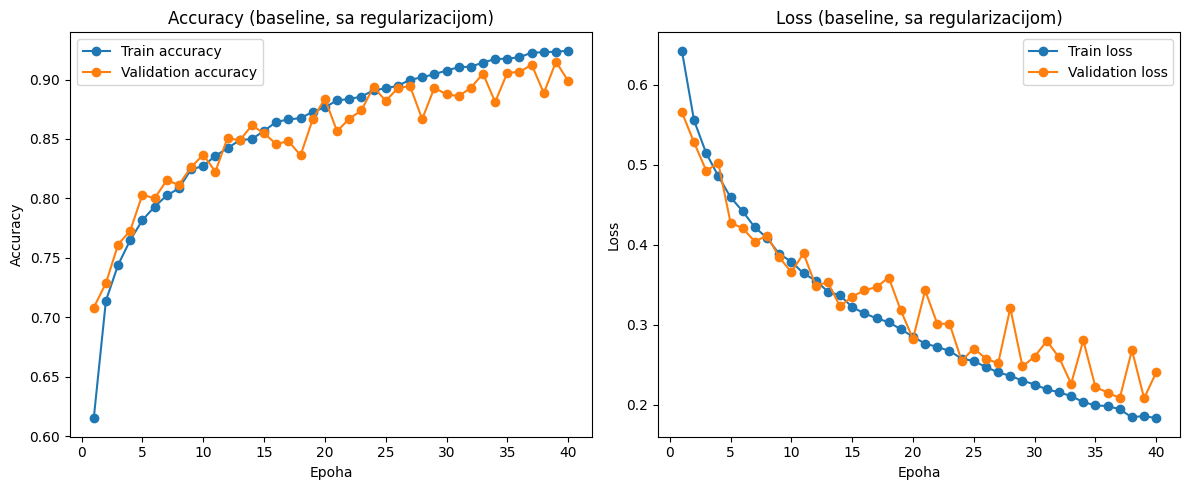

In [ ]:
train_accuracy_r = history_regularized.history["accuracy"]
val_accuracy_r = history_regularized.history["val_accuracy"]
train_loss_r = history_regularized.history["loss"]
val_loss_r = history_regularized.history["val_loss"]
epochs_range_r = range(1, len(train_accuracy_r) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range_r, train_accuracy_r, marker="o", label="Train accuracy")
axes[0].plot(epochs_range_r, val_accuracy_r, marker="o", label="Validation accuracy")
axes[0].set_title("Accuracy (baseline, sa regularizacijom)")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_range_r, train_loss_r, marker="o", label="Train loss")
axes[1].plot(epochs_range_r, val_loss_r, marker="o", label="Validation loss")
axes[1].set_title("Loss (baseline, sa regularizacijom)")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Finalna evaluacija na test skupu

Isti format metrika kao u `03_transfer_learning.ipynb`, radi lakšeg poređenja modela u `06_demo`: accuracy, precision, recall, F1-score i matrica konfuzije, na test skupu (1.000 slika) koji nije korišćen ni za trening ni za biranje hiperparametara.


In [ ]:
# evaluate() računa ukupan loss/accuracy nad celim test skupom
test_loss, test_accuracy = regularized_model.evaluate(test_dataset, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy (%): {test_accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9030 - loss: 0.2537
Test loss: 0.2537
Test accuracy: 0.9030
Test accuracy (%): 90.30%


In [ ]:
# predict() daje verovatnoće (0-1) za svaku sliku
y_prob = regularized_model.predict(test_dataset, verbose=1).ravel()
# prag 0.5 pretvara verovatnoću u klasu (0=cat, 1=dog)
y_pred = (y_prob >= 0.5).astype(int)
# test_dataset NIJE mešan (training=False), pa se redosled predikcija poklapa sa test_df
y_true = test_df["label_index"].to_numpy()

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=["cat", "dog"]))

Accuracy:  0.9030
Precision: 0.8974
Recall:    0.9100
F1-score:  0.9037
              precision    recall  f1-score   support

         cat       0.91      0.90      0.90       500
         dog       0.90      0.91      0.90       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



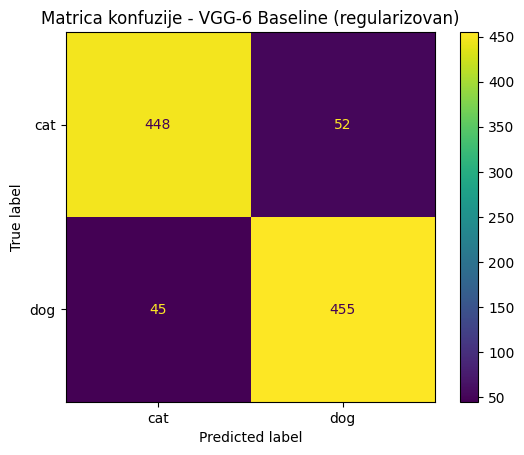

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# matrica konfuzije pokazuje TAČNO koliko je slika svake klase pogrešno klasifikovano kao druga
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
disp.plot(values_format="d")
plt.title("Matrica konfuzije - VGG-6 Baseline (regularizovan)")
plt.show()

## 8. Čuvanje modela

Čuvamo samo finalnu (regularizovanu) verziju modela — ona predstavlja naš stvarni baseline rezultat za poređenje sa transfer learning i fine-tuning pristupima.


In [ ]:
# čuvamo SAMO finalnu (regularizovanu) verziju - ona je naš stvarni baseline rezultat.
# Isti obrazac foldera (MU-projekat/models) kao kod Mine, radi doslednosti
MODEL_DIR = "/content/drive/MyDrive/MU-projekat/models"
os.makedirs(MODEL_DIR, exist_ok=True)

BASELINE_MODEL_PATH = os.path.join(MODEL_DIR, "vgg6_baseline_regularized.keras")
regularized_model.save(BASELINE_MODEL_PATH)

print("Model sačuvan na:", BASELINE_MODEL_PATH)
print("Model uspešno sačuvan:", os.path.exists(BASELINE_MODEL_PATH))

Model sačuvan na: /content/drive/MyDrive/MU-projekat/models/vgg6_baseline_regularized.keras
Model uspešno sačuvan: True


## Zaključak

Baseline model (VGG-6, treniran od nule) jasno je pokazao očekivano ponašanje:

**Bez regularizacije**: train accuracy je dostigao 99.66%, dok je validation accuracy oscilovao oko 83-85% — validation loss je nakon epohe ~7 počeo da RASTE (0.36 → 0.91) dok je train loss nastavio da pada ka nuli — klasičan primer overfitovanja.

**Sa Dropout + data augmentation**: train i validation krive ostaju blizu tokom celog treninga, bez razmicanja. Na test skupu (1.000 slika, nikad viđenih tokom treninga):
- Accuracy: 90.30%
- Precision: 89.74%
- Recall: 91.00%
- F1-score: 90.37%

Matrica konfuzije pokazuje uravnotežene greške (52 mačke pogrešno klasifikovane kao pas, 45 pasa pogrešno klasifikovano kao mačka) — nema pristrasnosti ka jednoj klasi.

Ovi rezultati (90.30% test accuracy) premašuju baseline rezultat iz referentnog rada (Lin, 2020: ~86% validation accuracy), i služe kao donja granica za poređenje sa transfer learning (`03_transfer_learning.ipynb`: 98.10% test accuracy) i fine-tuning (`04_finetuning.ipynb`) pristupima u `06_demo.ipynb`.
